# Import All Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Load Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/fashion-mnist_train.csv")

In [6]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df.shape

(60000, 785)

# Visualize Images

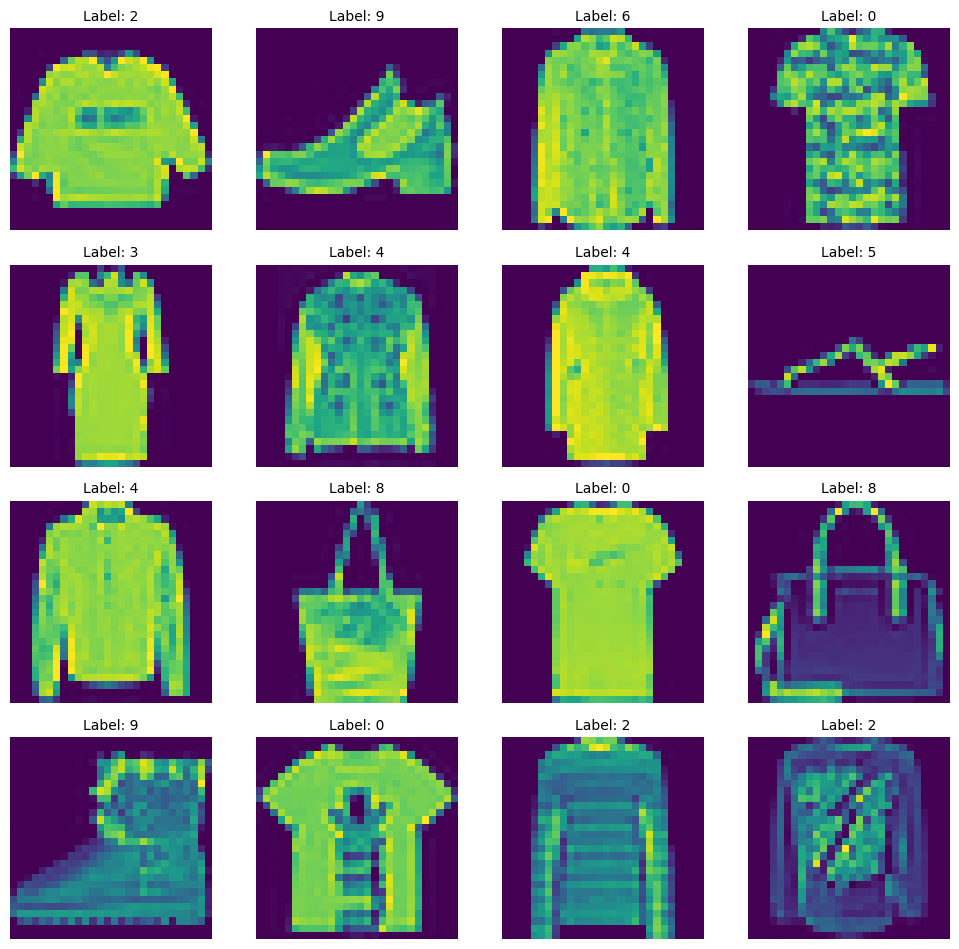

In [8]:
# Create a 4×4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

# Display first 16 images
for i, ax in enumerate(axes.flat):
    image = df.iloc[i,1:].values.reshape(28, 28)

    ax.imshow(image)
    ax.set_title(f"Label: {df.iloc[i,0]}", fontsize=10)
    ax.axis("off")

# Improve spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Train & Test Split

In [9]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Scaling the features
X_train = X_train / 255.0
X_test = X_test / 255.0

# Data Preparation

In [12]:
# Custom Dataset Class

class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long) # CrossEntropyLoss requires integer indices (long) for labels

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]


In [13]:
# train test dataset object
train_dataset = CustomDataset(X_train,  y_train)
test_dataset = CustomDataset(X_test, y_test)

In [14]:
# create train and test loader
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False) # We dont want to shuffle data on testing

# Hyperparameter Tuning

1. Number of hidden layer
2. Neurons per layer
3. Number of epochs
4. Optimizer
5. Learning rate
6. Batch Size
7. Dropout rate
8. Weight decay(lambda)

# Round 1

1. Number of hidden layer
2. Neurons per layer

# Objective Function

In [22]:
class MyNN(nn.Module):

  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer):
    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(0.3))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer,output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)

In [23]:
# objective function
def objective(trial):

  # next hyperparameter value from the search space
  num_hidden_layer = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)

  # model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim,output_dim,num_hidden_layer,neurons_per_layer).to(device)

  # parameter init
  epochs = 50
  learning_rate = 0.01

  # optimizer selection
  loss_function = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr = learning_rate, weight_decay=1e-4)

  # training loop
  # Step - 1 define loop for epoch
  for epoch in range(epochs):

    model.train()
    total_epoch_loss = 0

    # Step - 2 Mini-Batch
    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # Step - 3 forward pass
      y_pred = model(batch_features)

      # Step - 4 loss calculate
      loss = loss_function(y_pred,batch_labels)

      # Step - 5 Zero gradients
      optimizer.zero_grad()

      # Step - 6 backward pass
      loss.backward()

      # Step - 7 parameter update
      optimizer.step()

  # evaluation
  model.eval()

  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features) # give 32x10 size matrix

      predicted = torch.argmax(outputs, 1) # get label of images

      total += batch_labels.shape[0] # Total labels

      correct += (predicted == batch_labels).sum().item() # total correct labels

  Accuracy = correct/total

  return Accuracy

In [18]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 27.3 MB/s eta 0:00:00


In [24]:
import optuna

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-08-19 14:21:14,405] A new study created in memory with name: no-name-9a66b56a-8de5-4451-b6b5-3c84d1da48d2
[I 2026-08-19 14:22:26,792] Trial 0 finished with value: 0.921125 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 112}. Best is trial 0 with value: 0.921125.
[I 2026-08-19 14:23:09,328] Trial 1 finished with value: 0.9162916666666666 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 104}. Best is trial 0 with value: 0.921125.
[I 2026-08-19 14:24:01,021] Trial 2 finished with value: 0.9033958333333333 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 48}. Best is trial 0 with value: 0.921125.
[I 2026-08-19 14:25:00,301] Trial 3 finished with value: 0.9129791666666667 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 72}. Best is trial 0 with value: 0.921125.
[I 2026-08-19 14:25:59,876] Trial 4 finished with value: 0.6650208333333333 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 8}. Best is trial 0 with value: 

In [25]:
study.best_value

0.921125

In [26]:
study.best_params

{'num_hidden_layers': 4, 'neurons_per_layer': 112}

# Round 2

1. Number of hidden layer
2. Neurons per layer
3. Number of epochs
4. Optimizer
5. Learning rate
6. Batch Size
7. Dropout rate
8. Weight decay(lambda)

In [27]:
class MyNN(nn.Module):

  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate):
    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer,output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)

In [36]:
# objective function
def objective(trial):

  # next hyperparameter value from the search space
  num_hidden_layer = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 100, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  # create train and test loader
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # We dont want to shuffle data on testing

  # model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim,output_dim,num_hidden_layer,neurons_per_layer,dropout_rate).to(device)


  # optimizer selection
  loss_function = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr = learning_rate, weight_decay=1e-4)

  if optimizer_name == "Adam":
    optim.Adam(model.parameters(), lr = learning_rate, weight_decay=weight_decay)
  elif optimizer_name == "SGD":
    optim.SGD(model.parameters(), lr = learning_rate, weight_decay=weight_decay)
  else:
    optim.RMSprop(model.parameters(), lr = learning_rate, weight_decay=weight_decay)

  # training loop
  # Step - 1 define loop for epoch
  for epoch in range(epochs):

    model.train()
    total_epoch_loss = 0

    # Step - 2 Mini-Batch
    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # Step - 3 forward pass
      y_pred = model(batch_features)

      # Step - 4 loss calculate
      loss = loss_function(y_pred,batch_labels)

      # Step - 5 Zero gradients
      optimizer.zero_grad()

      # Step - 6 backward pass
      loss.backward()

      # Step - 7 parameter update
      optimizer.step()

  # evaluation
  model.eval()

  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features) # give 32x10 size matrix

      predicted = torch.argmax(outputs, 1) # get label of images

      total += batch_labels.shape[0] # Total labels

      correct += (predicted == batch_labels).sum().item() # total correct labels

  Accuracy = correct/total

  return Accuracy

In [37]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-08-19 15:09:19,927] A new study created in memory with name: no-name-6c6ee24b-9c40-48d7-aaa2-1b7a425601cc
[I 2026-08-19 15:10:19,298] Trial 0 finished with value: 0.7858958333333333 and parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 80, 'epochs': 20, 'learning_rate': 0.0008372762895677077, 'dropout_rate': 0.34772593578590916, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 3.1251563555449766e-05}. Best is trial 0 with value: 0.7858958333333333.
[I 2026-08-19 15:10:30,372] Trial 1 finished with value: 0.8882708333333333 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 128, 'epochs': 10, 'learning_rate': 0.030878481337146938, 'dropout_rate': 0.47679712000756236, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0008287093351136799}. Best is trial 1 with value: 0.8882708333333333.
[I 2026-08-19 15:12:21,413] Trial 2 finished with value: 0.8997083333333333 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 120, 'epochs': 80, 'lea

In [38]:
study.best_value


0.8997083333333333

In [40]:
study.best_params

{'num_hidden_layers': 4,
 'neurons_per_layer': 120,
 'epochs': 80,
 'learning_rate': 0.001072683930503523,
 'dropout_rate': 0.16614069898482944,
 'batch_size': 128,
 'optimizer': 'Adam',
 'weight_decay': 0.0006610338126052841}